# Projet PageRank

## Objectif

Dans ce projet, on étudie l’algorithme **PageRank** sur un graphe aléatoire orienté de type **Erdős–Rényi**.

L’idée est de modéliser la navigation d’un utilisateur sur un graphe comme une **chaîne de Markov**, puis de calculer la **distribution stationnaire** de cette chaîne par la **méthode de la puissance itérée**.  
Cette distribution stationnaire fournit un **score d’importance** pour chaque sommet du graphe.

On compare ensuite ce PageRank théorique avec une estimation obtenue par **simulation de marches aléatoires** de longueurs \(10^3,10^4,10^5,10^6,10^7\), comme demandé dans l’énoncé.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# Générateur aléatoire reproductible
rng = np.random.default_rng(42)

## 1. Choix des paramètres

On choisit :

- \(N = 1000\) sommets ;
- une probabilité de lien \(p = 0.01\) pour le modèle d’Erdős–Rényi ;
- un paramètre de téléportation \(lpha = 0.85\) pour la matrice PageRank.

Pour rendre les expériences **reproductibles**, on fixe également une graine aléatoire.

In [3]:
N = 1000 # nombre de sommets
p = 0.01 # probabilité d'arête (Erdős–Rényi)
alpha = 0.85 # paramètre de téléportation 

## 2. Génération du graphe Erdős–Rényi


Chaque arête dirigée $(i \to j)$, $i \neq j$, existe indépendamment avec probabilité $p$.

- Pour $N=1000$ et $p=0.01$, le degré sortant moyen est $\approx Np = 10$, ce qui donne un graphe bien connecté mais pas trivial.

On génère une matrice d’adjacence $A$ telle que :

- \(A_{ij}=1\) s’il existe une arête orientée de \(i\) vers \(j\) ;
- \(A_{ij}=0\) sinon.

Les arêtes sont générées indépendamment avec probabilité \(p\).  
On enlève les boucles \(i 	o i\).

In [4]:
A = (rng.random((N, N)) < p).astype(int)
np.fill_diagonal(A, 0)

print("Taille de A :", A.shape)
print("Nombre total d'arêtes :", A.sum())
print("Nombre moyen de liens sortants :", A.sum(axis=1).mean())

out_degree = A.sum(axis=1)
print("Nombre de sommets sans lien sortant :", np.sum(out_degree == 0))

Taille de A : (1000, 1000)
Nombre total d'arêtes : 10054
Nombre moyen de liens sortants : 10.054
Nombre de sommets sans lien sortant : 0


La matrice \(A\) décrit uniquement la **structure** du graphe : elle indique s’il existe ou non un lien entre deux sommets.

Elle n’est pas encore probabiliste. Pour construire une chaîne de Markov, il faut transformer chaque ligne en **loi de probabilité**.

## 3. Construction de la matrice de transition $P$

À partir de la matrice d’adjacence, on construit une matrice de transition $P$.

- si un sommet possède des liens sortants, la probabilité est répartie uniformément entre ses voisins ;
- si un sommet n’a aucun lien sortant, on lui associe une distribution uniforme sur l’ensemble des sommets.

Ainsi, chaque ligne de $P$ somme à 1.

In [5]:
P = np.zeros((N, N))

for i in range(N):
    if out_degree[i] > 0:
        P[i] = A[i] / out_degree[i]
    else:
        P[i] = np.ones(N) / (N - 1)
        P[i, i] = 0    #teleportation totale pour les dangling nodes

In [6]:
print("Sommes des 5 premières lignes de P :", P.sum(axis=1)[:5])
print("Minimum de P :", P.min())
print("Maximum de P :", P.max())
print("Erreur max somme lignes P :", np.abs(P.sum(axis=1) - 1).max())

Sommes des 5 premières lignes de P : [1. 1. 1. 1. 1.]
Minimum de P : 0.0
Maximum de P : 0.5
Erreur max somme lignes P : 2.220446049250313e-16


Chaque ligne de la matrice $P$ représente une loi de probabilité : elle décrit la probabilité de transition vers les autres sommets à partir d’un sommet donné.

Autrement dit, $P_{ij}$ est la probabilité de passer du sommet $i$ au sommet $j$ si l’on suit uniquement les liens du graphe.

## 4. Matrice PageRank $G$ et propriétés probabilistes

Pour PageRank, on introduit une matrice $\Delta$ correspondant à un saut aléatoire uniforme vers un autre sommet, la matrice PageRank est alors :

$$G = \alpha P + (1-\alpha)\Delta, \qquad \Delta_{ij} = \begin{cases} 0 & i=j \\ \frac{1}{N-1} & i \neq j \end{cases}$$

Cette modification évite les blocages liés à la structure du graphe.

In [7]:
Delta = np.ones((N, N)) / (N - 1)
np.fill_diagonal(Delta, 0)

G = alpha * P + (1 - alpha) * Delta

In [8]:
print("Sommes des 5 premières lignes de Delta :", Delta.sum(axis=1)[:5])
print("Sommes des 5 premières lignes de G :", G.sum(axis=1)[:5])
print("Erreur max sur somme des lignes de G :", np.max(np.abs(G.sum(axis=1) - 1)))
print("Minimum de G :", G.min())
print("Maximum de G :", G.max())

Sommes des 5 premières lignes de Delta : [1. 1. 1. 1. 1.]
Sommes des 5 premières lignes de G : [1. 1. 1. 1. 1.]
Erreur max sur somme des lignes de G : 9.992007221626409e-16
Minimum de G : 0.0
Maximum de G : 0.4251501501501501


La matrice $G$ mélange deux comportements :

- avec probabilité $\alpha$, le surfeur suit la structure du graphe ;
- avec probabilité $\alpha$, il saute vers un autre sommet.

C’est cette matrice $G$ qui définit la chaîne de Markov de PageRank.

## 5. Calcul de la distribution stationnaire par puissance itérée

On cherche $\pi$ tel que $\pi G = \pi$, $\sum_i \pi_i = 1$.

Ce vecteur $\pi$ est la distribution stationnaire de la chaîne : il représente la fréquence de visite à long terme des sommets.

On l’obtient par puissance itérée en partant d’une distribution uniforme.

In [9]:
def power_iteration(G, n_iter=100):
    N = G.shape[0]
    pi = np.ones(N) / N
    history = []
    for k in range(n_iter):
        pi_new = pi @ G
        history.append(np.linalg.norm(pi_new - pi, 1))
        pi = pi_new
    return pi, history

pi_m, convergence_history = power_iteration(G, 100)

print(f"Somme de pi   : {pi_m.sum():.10f}")
print(f"Min de pi     : {pi_m.min():.8f}")
print(f"Max de pi     : {pi_m.max():.8f}")

Somme de pi   : 1.0000000000
Min de pi     : 0.00034774
Max de pi     : 0.00200600


Le vecteur $\pi$ correspond au **PageRank théorique**.  
Plus une composante $\pi_i$ est grande, plus le sommet $i$ est considéré comme important.

In [10]:
ranking = np.argsort(-pi_m)

print("Top 10 sommets les plus importants :", ranking[:10])
print("Top 10 scores PageRank :", np.round(pi_m[ranking[:10]], 6))

Top 10 sommets les plus importants : [165 869 990 403  58 844  27 201 989 667]
Top 10 scores PageRank : [0.002006 0.001979 0.001948 0.001947 0.001925 0.001853 0.001839 0.001744
 0.001733 0.001727]


- Visualisation des plus grands scores PageRank

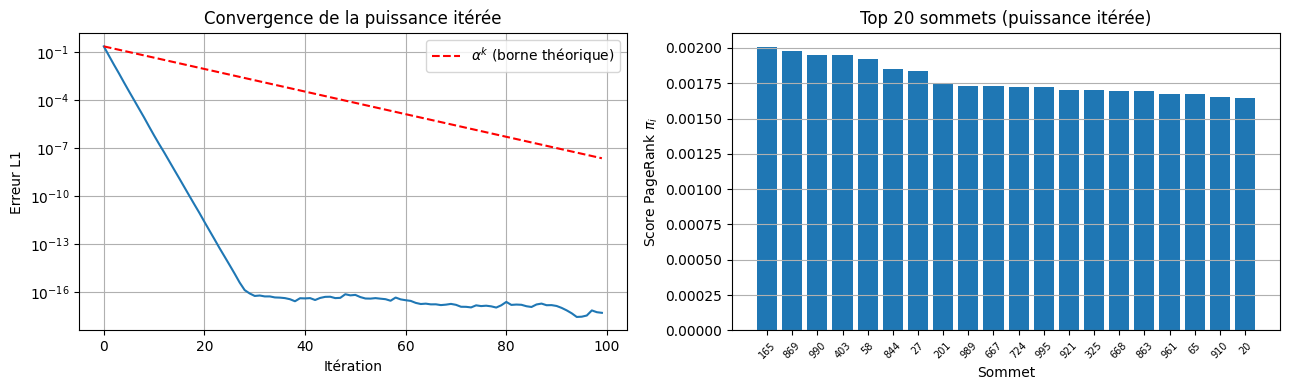

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Convergence de la puissance itérée
axes[0].semilogy(convergence_history)
# Référence théorique alpha^k
iters = np.arange(len(convergence_history))
axes[0].semilogy(iters, convergence_history[0] * alpha**iters, 'r--', label=r'$\alpha^k$ (borne théorique)')
axes[0].set_xlabel("Itération")
axes[0].set_ylabel("Erreur L1")
axes[0].set_title("Convergence de la puissance itérée")
axes[0].legend()
axes[0].grid(True)

# Top 20 PageRank
sigma_m = np.argsort(-pi_m)
top20 = sigma_m[:20]
axes[1].bar(range(20), pi_m[top20])
axes[1].set_xticks(range(20))
axes[1].set_xticklabels(top20, rotation=45, fontsize=7)
axes[1].set_xlabel("Sommet")
axes[1].set_ylabel("Score PageRank $\\pi_i$")
axes[1].set_title("Top 20 sommets (puissance itérée)")
axes[1].grid(True, axis='y')

plt.tight_layout()
plt.show()

## 7. Simulation de marches aléatoires

On simule la chaîne de Markov de matrice $G$ pendant $T = 10^n$ pas ($n = 3, 4, 5, 6, 7$).  


In [15]:
lengths = [10**3, 10**4, 10**5, 10**6, 10**7]

In [16]:
def simulate_random_walk(G, T, rng, start_node=None):
    """
    Simule une marche aléatoire de longueur T sur un graphe de matrice de transition G.
    """
    N = G.shape[0]

    if start_node is None:
        current_node = rng.integers(N)
    else:
        current_node = start_node

    initial_node = current_node
    visits = np.zeros(N, dtype=int)

    for _ in range(T):
        visits[current_node] += 1
        current_node = rng.choice(N, p=G[current_node])

    pi_sim = visits / T
    return pi_sim, visits, initial_node

### Simulation pour les longueurs $10^3,10^4,10^5,10^6,10^7$

In [17]:
pi_sims = []
visits_list = []
errors_L1 = []
start_nodes = []

for T in lengths:
    pi_sim, visits, start_node = simulate_random_walk(G, T, rng)
    pi_sims.append(pi_sim)
    visits_list.append(visits)
    start_nodes.append(start_node)
    error = np.linalg.norm(pi_sim - pi_m, 1)
    errors_L1.append(error)

In [18]:
for i, T in enumerate(lengths):
    print(f"T = {T}")
    print(f"  Sommet de départ : {start_nodes[i]}")
    print(f"  Somme des fréquences : {pi_sims[i].sum():.6f}")
    print(f"  Minimum : {pi_sims[i].min():.6f}")
    print(f"  Maximum : {pi_sims[i].max():.6f}")
    print()

T = 1000
  Sommet de départ : 559
  Somme des fréquences : 1.000000
  Minimum : 0.000000
  Maximum : 0.005000

T = 10000
  Sommet de départ : 698
  Somme des fréquences : 1.000000
  Minimum : 0.000100
  Maximum : 0.002600

T = 100000
  Sommet de départ : 326
  Somme des fréquences : 1.000000
  Minimum : 0.000330
  Maximum : 0.002180

T = 1000000
  Sommet de départ : 773
  Somme des fréquences : 1.000000
  Minimum : 0.000324
  Maximum : 0.002057

T = 10000000
  Sommet de départ : 923
  Somme des fréquences : 1.000000
  Minimum : 0.000344
  Maximum : 0.002021



- Résultats numériques
On affiche l’erreur entre la distribution simulée $\pi_s^{(n)}$ et la distribution théorique $\pi$, mesurée avec la norme $L^1$.

In [19]:
for i, T in enumerate(lengths):
    print(f"Longueur de marche T = {T:>8}  |  erreur L1 = {errors_L1[i]:.6f}")

Longueur de marche T =     1000  |  erreur L1 = 0.793997
Longueur de marche T =    10000  |  erreur L1 = 0.251440
Longueur de marche T =   100000  |  erreur L1 = 0.078739
Longueur de marche T =  1000000  |  erreur L1 = 0.024844
Longueur de marche T = 10000000  |  erreur L1 = 0.008169


<>:5: SyntaxWarning: invalid escape sequence '\p'
<>:5: SyntaxWarning: invalid escape sequence '\p'
/var/folders/ps/jwcn888s0sgbqr6m1krl_zt80000gn/T/ipykernel_18410/2340068918.py:5: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel("Erreur L1 entre $\pi_s^{(n)}$ et $\pi$")


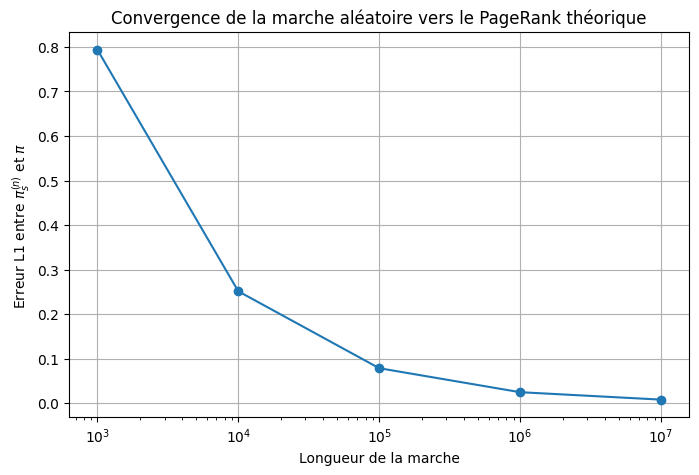

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(lengths, errors_L1, marker="o")
plt.xscale("log")
plt.xlabel("Longueur de la marche")
plt.ylabel("Erreur L1 entre $\pi_s^{(n)}$ et $\pi$")
plt.title("Convergence de la marche aléatoire vers le PageRank théorique")
plt.grid(True)
plt.show()

On s’attend à ce que l’erreur diminue lorsque la longueur de la marche augmente.

In [21]:
for i, T in enumerate(lengths):
    ranking_sim = np.argsort(-pi_sims[i])
    top10_nodes = ranking_sim[:10]
    top10_scores = pi_sims[i][top10_nodes]

    print(f"\nT = {T}")
    print("Top 10 des sommets simulés :", top10_nodes)
    print("Fréquences correspondantes :", np.round(top10_scores, 6))


T = 1000
Top 10 des sommets simulés : [731 652 915 685 369 930 657 118 660  32]
Fréquences correspondantes : [0.005 0.005 0.005 0.005 0.004 0.004 0.004 0.004 0.004 0.004]

T = 10000
Top 10 des sommets simulés : [403 563 844 512 667  19 149 283 246 824]
Fréquences correspondantes : [0.0026 0.0024 0.0023 0.0023 0.0023 0.0023 0.0022 0.0022 0.0022 0.0022]

T = 100000
Top 10 des sommets simulés : [869 844 165  27 403  58 724 863 300 990]
Fréquences correspondantes : [0.00218 0.00216 0.00216 0.00206 0.00204 0.00194 0.00189 0.00187 0.00185
 0.0018 ]

T = 1000000
Top 10 des sommets simulés : [165 990  58 403 869  27 844 995 667 668]
Fréquences correspondantes : [0.002057 0.002008 0.001984 0.001963 0.001897 0.001864 0.001835 0.001791
 0.001779 0.001752]

T = 10000000
Top 10 des sommets simulés : [165 403 869 990  58 844  27 201 989 995]
Fréquences correspondantes : [0.002021 0.001966 0.001966 0.001945 0.001928 0.001869 0.001846 0.00174
 0.001728 0.001722]


## 8. Classements (permutations) $\sigma_m$ et $\sigma_s^{(n)}$
On construit maintenant les classements des sommets en triant les composantes des vecteurs PageRank.

- $\sigma_m$ : classement théorique obtenu par puissance itérée ;
- $\sigma_s^{(n)}$ : classement simulé pour chaque longueur de marche.

In [22]:
sigma_m = np.argsort(-pi_m)

sigma_s_list = []
for pi_sim in pi_sims:
    sigma_s = np.argsort(-pi_sim)
    sigma_s_list.append(sigma_s)

Comme indicateur secondaire, on compare les 20 sommets les mieux classés dans les deux méthodes.

In [23]:
top20_m = set(sigma_m[:20])

top20_overlap = []
for sigma_s in sigma_s_list:
    top20_s = set(sigma_s[:20])
    overlap = len(top20_m.intersection(top20_s))
    top20_overlap.append(overlap)

In [24]:
for i, T in enumerate(lengths):
    print(f"T = {T}  |  Sommets communs dans le top 20 : {top20_overlap[i]}/20")

T = 1000  |  Sommets communs dans le top 20 : 0/20
T = 10000  |  Sommets communs dans le top 20 : 5/20
T = 100000  |  Sommets communs dans le top 20 : 17/20
T = 1000000  |  Sommets communs dans le top 20 : 18/20
T = 10000000  |  Sommets communs dans le top 20 : 19/20


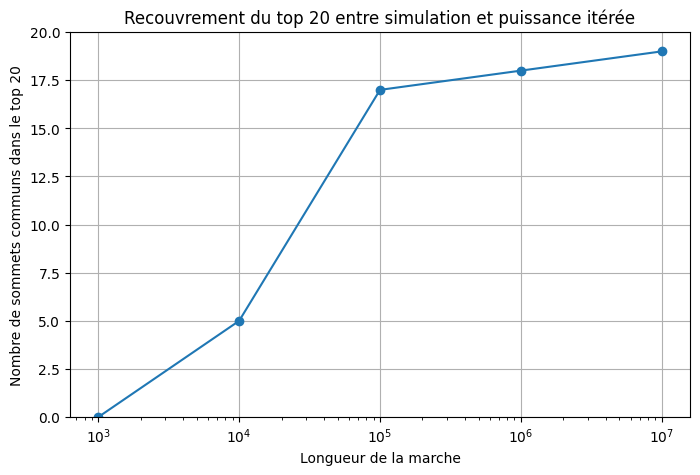

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(lengths, top20_overlap, marker="o")
plt.xscale("log")
plt.xlabel("Longueur de la marche")
plt.ylabel("Nombre de sommets communs dans le top 20")
plt.title("Recouvrement du top 20 entre simulation et puissance itérée")
plt.ylim(0, 20)
plt.grid(True)
plt.show()

## Distance entre permutations

On choisit la **distance de Spearman footrule** :

$F(\sigma_1,\sigma_2)=\sum_{i=1}^N |\mathrm{rang}_{\sigma_1}(i)-\mathrm{rang}_{\sigma_2}(i)|$

Cette distance est simple à interpréter : elle mesure l’écart total de position des sommets entre deux classements.

In [34]:
def compute_ranks(sigma):
    """
    Transforme une permutation sigma en tableau de rangs.
    sigma[position] = sommet placé à cette position
    ranks[node] = rang du sommet node
    """
    N = len(sigma)
    ranks = np.zeros(N, dtype=int)

    for position, node in enumerate(sigma):
        ranks[node] = position

    return ranks


def spearman_footrule(sigma1, sigma2):
    """
    Calcule la distance de Spearman footrule entre deux permutations.
    """
    ranks1 = compute_ranks(sigma1)
    ranks2 = compute_ranks(sigma2)
    return np.sum(np.abs(ranks1 - ranks2))

In [35]:
spearman_distances = []

for sigma_s in sigma_s_list:
    dist = spearman_footrule(sigma_m, sigma_s)
    spearman_distances.append(dist)

In [28]:
for i, T in enumerate(lengths):
    print(f"T = {T}  |  Distance de Spearman = {spearman_distances[i]:.0f}")

T = 1000  |  Distance de Spearman = 287550
T = 10000  |  Distance de Spearman = 183482
T = 100000  |  Distance de Spearman = 75226
T = 1000000  |  Distance de Spearman = 24444
T = 10000000  |  Distance de Spearman = 8344


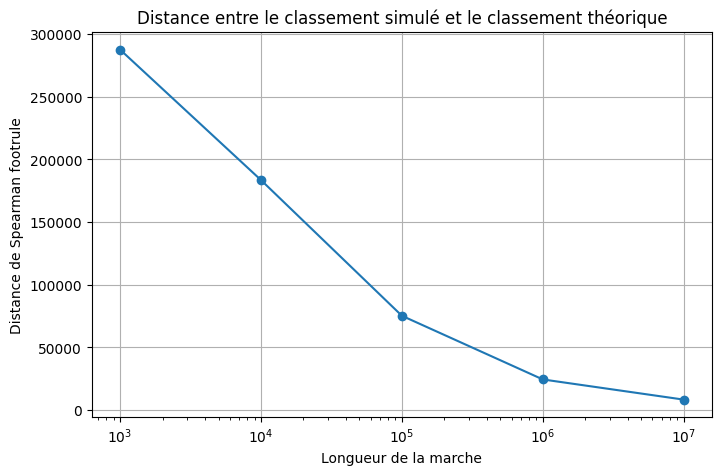

In [30]:
plt.figure(figsize=(8, 5))
plt.plot(lengths, spearman_distances, marker="o")
plt.xscale("log")
plt.xlabel("Longueur de la marche")
plt.ylabel("Distance de Spearman footrule")
plt.title("Distance entre le classement simulé et le classement théorique")
plt.grid(True)
plt.show()

On observe que la distance de Spearman entre le classement simulé et le classement théorique diminue lorsque la longueur de la marche augmente.

Cela montre que la marche aléatoire permet d’approcher progressivement le classement PageRank obtenu par la puissance itérée.

## 9. Bonus — PageRank sur un graphe réel (réseau de citations)

On applique PageRank au graphe **Karate Club** de Zachary (réseau social classique) via NetworkX, pour illustrer l'application à un graphe réel.

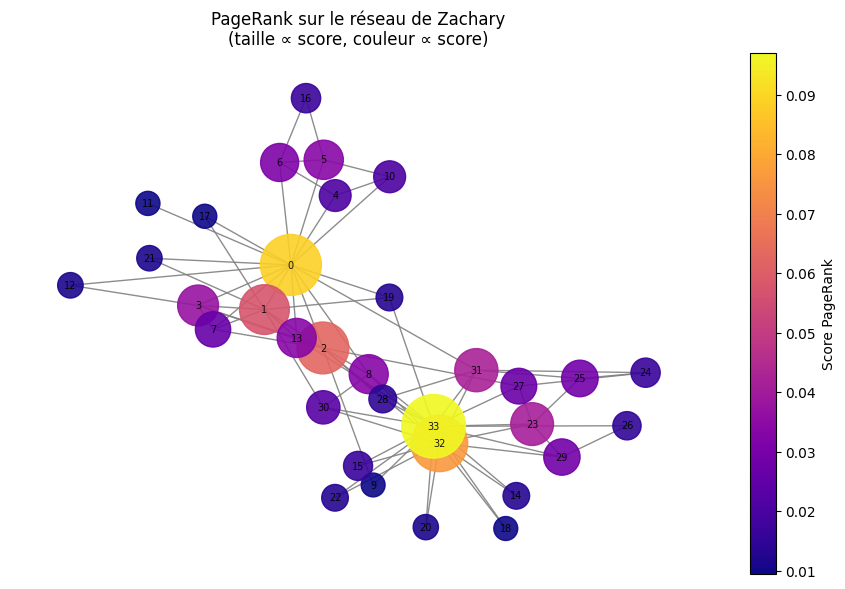

Top 5 nœuds par PageRank :
  1. Nœud 33  |  PageRank = 0.09698  |  Degré = 17
  2. Nœud  0  |  PageRank = 0.08851  |  Degré = 16
  3. Nœud 32  |  PageRank = 0.07593  |  Degré = 12
  4. Nœud  2  |  PageRank = 0.06277  |  Degré = 10
  5. Nœud  1  |  PageRank = 0.05741  |  Degré = 9


In [38]:
# Graphe réel : réseau social de Zachary (34 nœuds)
G_real = nx.karate_club_graph()
G_real_directed = G_real.to_directed()

# PageRank via NetworkX (référence)
pr_nx = nx.pagerank(G_real_directed, alpha=0.85)
nodes = list(G_real_directed.nodes())
pr_values = np.array([pr_nx[n] for n in nodes])

# Visualisation
fig, ax = plt.subplots(figsize=(9, 6))
pos = nx.spring_layout(G_real, seed=42)
node_size = pr_values / pr_values.max() * 2000 + 100
nx.draw_networkx(
    G_real, pos, ax=ax,
    node_size=node_size,
    node_color=pr_values,
    cmap='plasma',
    with_labels=True,
    font_size=7,
    edge_color='gray',
    alpha=0.9
)
sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(pr_values.min(), pr_values.max()))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Score PageRank')
ax.set_title("PageRank sur le réseau de Zachary\n(taille ∝ score, couleur ∝ score)", fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.show()

# Top 5
top5_idx = np.argsort(-pr_values)[:5]
print("Top 5 nœuds par PageRank :")
for rank, idx in enumerate(top5_idx, 1):
    node = nodes[idx]
    print(f"  {rank}. Nœud {node:>2}  |  PageRank = {pr_values[idx]:.5f}  |  Degré = {G_real.degree(node)}")

Les nœuds 0 et 33 obtiennent les scores PageRank les plus élevés — ils correspondent aux deux leaders du club (l'instructeur et le président), dont le retrait a causé la scission du club. Le PageRank retrouve bien les nœuds structurellement centraux, pas simplement les plus connectés (degré).

## 10. Conclusion

Dans ce travail, nous avons :

1. généré un graphe aléatoire orienté d’Erdős–Rényi ;
2. construit la matrice de transition $P$, puis la matrice PageRank $G$ ;
3. calculé la distribution stationnaire théorique par puissance itérée ;
4. simulé des marches aléatoires de longueurs $10^3,10^4,10^5,10^6,10^7$ ;
5. comparé les vecteurs PageRank théoriques et simulés ;
6. comparé les classements obtenus à l’aide d’une distance entre permutations.
7. Appliqué PageRank au réseau de Zachary (graphe réel), retrouvant les nœuds structurellement importants.

Le comportement observé est conforme à la théorie : lorsque la longueur de la marche augmente, la distribution simulée et le classement simulé se rapprochent de ceux obtenus par puissance itérée.